**Tabla de contenido**

- [Lectura de datos](#Lectura-de-datos)
- [Preprocesamiento](#Preprocesamiento)
- [Feature engineering](#Feature-engineering)
- [Modelación](#Modelacion)
    - [LSTM Single step](#LSTM-Single-step)

# Lectura de datos

In [1]:
import pandas as pd
import numpy as np
import os

file_path = lambda file: os.path.join(os.getcwd(),'data/walmart_sales',file)
train_df = pd.read_csv(file_path('train.csv'))
train_df.head(8)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False


In [2]:
stores_df = pd.read_csv(file_path('stores.csv'))
stores_df.head(8)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078


In [3]:
features_df = pd.read_csv(file_path('features.csv'))
features_df.head(8)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False


In [4]:
us_holiday_df = pd.read_csv(file_path('US Holiday Dates (2004-2021).csv'))
us_holiday_df.head(8)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006
3,2007-07-04,4th of July,Wednesday,7,4,2007
4,2008-07-04,4th of July,Friday,7,4,2008
5,2009-07-04,4th of July,Saturday,7,4,2009
6,2010-07-04,4th of July,Sunday,7,4,2010
7,2011-07-04,4th of July,Monday,7,4,2011


Veamos ahora cual es la fecha máxima y miníma para los datos de entrenamiento. Así mismo, veamos cuantos registros hay en el dataframe de entrenamiento

In [5]:
print(f"La fecha mínima es: {train_df["Date"].min()} y la máxima es {train_df["Date"].max()}")
print(f"el dataset tiene un total de {len(train_df)} registros")

La fecha mínima es: 2010-02-05 y la máxima es 2012-10-26
el dataset tiene un total de 421570 registros


# Preprocesamiento

Antes de preprocesar los datos, veamos si hay datos faltantes

In [6]:
train_df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Por lo que vemos, no hay datos faltantes. Ahora veamos si hay registros dúplicados.

In [7]:
duplicados = train_df[train_df.duplicated(subset=['Store','Dept'],keep=False)]
duplicados.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Podemos ver que si tenemos datos duplicados. Obtengamos un nuevo dataframe sin registros duplicados y solo conservaremos las columnas Store y Dept

In [8]:
combinations = train_df[["Store", "Dept"]].drop_duplicates()
combinations

,Store,Dept
0,1,1
143,1,2
286,1,3
429,1,4
572,1,5
...,...,...
421013,45,94
421147,45,95
421290,45,96
421292,45,97


Ahora, enfoquemonos en la columna Date, esta la convertiremos a formato Datetime, mandamos la fecha al index y ordenamos de forma ascendente.

In [9]:
process_df = train_df.copy()
process_df["Date"] = pd.to_datetime(process_df["Date"], format='%Y-%m-%d')
process_df.set_index("Date", inplace=True)
process_df.sort_index(inplace=True)
process_df.head()

,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,1,1,24924.50,False
2010-02-05,29,5,15552.08,False
2010-02-05,29,6,3200.22,False
2010-02-05,29,7,10820.05,False
2010-02-05,29,8,20055.64,False


Ahora que ya tenemos la fecha en el index, vamos a remuestrear el dataset de la siguiente forma.

- Rellenar los períodos semanales sin datos de ventas con 0 (asumiendo que no hubo ventas en esas semanas) y asegurar que todas las combinaciones de Store (tienda) + Dept (departamento) tengan un registro semanal continuo (incluso si no hubo ventas en ciertas semanas).

In [10]:
# Lista para almacenar DataFrames procesados
p_df_resampled_list = []

# Imputación de ventas semanales faltantes por cero
for _, row in combinations.iterrows():
    store_id, dept = row["Store"], row["Dept"]

    # Filtrar por tienda y departamento
    p_df = process_df[(process_df["Store"] == store_id) & (process_df["Dept"] == dept)]

    # Re-muestreo semanal (cada viernes) y completar valores faltantes
    p_df_resampled = p_df.resample('W-FRI').asfreq()

    # Rellenar valores faltantes
    p_df_resampled["Store"] = p_df_resampled["Store"].ffill() # rellena nan hacia adelante con el ultimos valor conocido
    p_df_resampled["Dept"] = p_df_resampled["Dept"].ffill()
    p_df_resampled["Weekly_Sales"] = p_df_resampled["Weekly_Sales"].fillna(0)

    # Agregar a la lista de resultados
    p_df_resampled_list.append(p_df_resampled)


Cón esto ya tenemos el dataframe con datos continuos y sin  huecos garantizando que cada tienda y departamento registre ventas todos los viernes.

In [11]:
processed_data = pd.concat(p_df_resampled_list)
processed_data = processed_data.reset_index()
processed_data.head()

,Date,Store,Dept,Weekly_Sales,IsHoliday
0,2010-02-05,1.0,1.0,24924.50,False
1,2010-02-12,1.0,1.0,46039.49,True
2,2010-02-19,1.0,1.0,41595.55,False
3,2010-02-26,1.0,1.0,19403.54,False
4,2010-03-05,1.0,1.0,21827.90,False


In [12]:
print(f"cantidad de registros en el df procesado {processed_data.shape}")
print(f"cantidad de registros en el df original {train_df.shape}")

cantidad de registros en el df procesado (449237, 5)
cantidad de registros en el df original (421570, 5)


Ahora, necesitamos que las tiendas y departamentos sean enteros. Así mismo, tranformamos la fecha a formato object 

In [13]:
processed_data["Store"] = processed_data["Store"].astype(int)
processed_data["Dept"] = processed_data["Dept"].astype(int)
processed_data["Date"] = processed_data["Date"].dt.strftime("%Y-%m-%d")

Veamos si el anterior proceso altero las ventas. Para esto veriquemos que la suma total de ventas semanales en el DataFrame processed_data sea prácticamente igual a la del DataFrame original train_df, con un margen de error muy pequeño (menor a 0.01)

In [14]:
diff = abs(processed_data["Weekly_Sales"].sum() - train_df["Weekly_Sales"].sum())
print(f"Diferencia absoluta en las sumas de ventas: {diff:.4f}")

assert diff < 0.01

Diferencia absoluta en las sumas de ventas: 0.0000


Esto es perfecto. La suma de las ventas procesadas es practicamente igual a la suma de las ventas originales. Entonces podemos decir que train_df = processed_data

In [15]:
train_df = processed_data

Ahora que ya tenemos un dataframe que contiene las ventas cada viernes. Procedamos a calcular  una fecha de corte. Esto lo vamos a hacer usando el dataframe process_df  que la copia del dataframe original.

- cut_date = max_date - pd.Timedelta(weeks=7, days=1) : esta línea calcula una nueva fecha que es exactamente 7 semanas y 1 día anterior a la fecha almacenada en max_date. 

Este tipo de operación es común cuando necesitas establecer una fecha de corte o umbral en el pasado para filtrar datos

In [16]:
max_date = max(process_df.index) # Fecha máxima
cut_date = max_date - pd.Timedelta(weeks=7, days=1)
print(f"la última fecha registada es {max_date} y la fecha de corte es {cut_date}")

la última fecha registada es 2012-10-26 00:00:00 y la fecha de corte es 2012-09-06 00:00:00


Ahora que ya conocemos la fecha máxima y la fecha de corte, vamos a :

1. Seleccionar un dataframe que contiene los datos desde la fecha de corte hasta el final de los datos
2. Contar cuántos registros (días/fechas) hay para cada combinación única de Store (tienda) y Dept (departamento) en el dataframe filtrado

In [17]:
count_train_df = process_df[cut_date:].reset_index() #1
count_train_df = count_train_df.groupby(["Store", "Dept"])["Date"].count().reset_index()
count_train_df.head()

,Store,Dept,Date
0,1,1,8
1,1,2,8
2,1,3,8
3,1,4,8
4,1,5,8


ok. Ahora seleccionemos solo las combinaciones de Store y Dept que tienen al menos 8 registros en el período seleccionado.

In [18]:
count_train_df = count_train_df[count_train_df["Date"]>=8]
count_train_df = count_train_df[["Store", "Dept"]]
count_train_df.shape

(2855, 2)

Ahora, vamos a conservar solo las combinaciones de tiendas y departamentos que tienen datos recientes y suficientes registros. Para esto, haremos un merge (unión) entre los datos históricos y la lista de tiendas y departamentos activos después de la fecha de corte

In [19]:
train_df = train_df.merge(count_train_df, on=["Store", "Dept"], how="inner")
train_df.shape

(406819, 5)

ok. Podemos ver que de 449237 datos, nos quedamos solo con 406819 registros.

Ahora lo que nos queda hacer es agregar las variables que se encuentran en el dataframe `Stores` al dataframe `train_df`. Estas variables son:
- Tipe
- Size

In [20]:
print(f"datos antes del merge {train_df.shape}")
merged_train_df = pd.merge(train_df, stores_df, on='Store', how='left')
print(f"Datos después del merge {merged_train_df.shape}")

datos antes del merge (406819, 5)
Datos después del merge (406819, 7)


In [21]:
merged_train_df.head()

,Date,Store,Dept,Weekly_Sales,IsHoliday,Type,Size
0,2010-02-05,1,1,24924.50,False,A,151315
1,2010-02-12,1,1,46039.49,True,A,151315
2,2010-02-19,1,1,41595.55,False,A,151315
3,2010-02-26,1,1,19403.54,False,A,151315
4,2010-03-05,1,1,21827.90,False,A,151315


Perfecto!. AHora agregemos las características que hay en el dataframe `Feature_df`. Este merge lo aremos usando las columnas `Store` y `Date`.

In [22]:
merged_train_df = pd.merge(merged_train_df, features_df.drop(columns="IsHoliday"), on=['Store', 'Date'], how='left')
merged_train_df.head()

,Date,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,2010-02-05,1,1,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,2010-02-12,1,1,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,2010-02-19,1,1,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,2010-02-26,1,1,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,2010-03-05,1,1,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


Ahora, crearemos una función que ajusta las fechas. En este caso como las ventas deben estar los viernes de cada semana, entonces conviertiremos las fechas de una columna en el viernes anterior o el mismo viernes más cercano hacia atrás.
Además, eliminaremos fechas repetidas después de ese cambio.

1. Si la columna no está en formato fecha, la convertimos usando `pd.to_datetime()
2. Lleva cada fecha al viernes anterior (o al mismo viernes si ya es viernes).
    - `x.weekday()` da el día de la semana (0 = lunes, ..., 4 = viernes).
    - El cálculo `((x.weekday() + (7-4)) % 7)` da cuántos días hay que restar para llegar al viernes más cercano hacia atrás.
        - 7-4 = 3 (viernes es el día 4 en weekday(), pero se usa este ajuste para calcular correctamente el retroceso).
        - Si la fecha es lunes (0): (0 + 3) % 7 = 3 → retrocede 3 días (viernes anterior).
        - Si la fecha es viernes (4): (4 + 3) % 7 = 0 → no retrocede (ya es viernes).
        - Si la fecha es domingo (6): (6 + 3) % 7 = 2 → retrocede 2 días (viernes anterior)
3. Si varias filas terminan con la misma fecha después del ajuste, se eliminan los duplicados.

In [23]:
def to_previous_friday(df: pd.DataFrame, date_col: str, ) -> pd.DataFrame:
    if not isinstance(df[date_col][0], pd.Timestamp): #1
        df[date_col] = pd.to_datetime(df[date_col])

    df[f"{date_col}"] = df[date_col].apply(lambda x: x - pd.DateOffset(days=((x.weekday() + (7-4)) % 7))) # 2
    df = df.drop_duplicates(subset=[date_col]) #3
    return df

Ahora al dataframe `us_holiday_df le hacemos lo siguiente:
1. Aplicamos la función creada para ajustar la fecha al viernes anterior
2. Creamos una nueva columna llamada IsHoliday que copia los valores de la columna Holiday
3. Seleccionar columnas de interes

In [24]:
us_holiday_df = to_previous_friday(us_holiday_df, "Date") #1
us_holiday_df["IsHoliday"] = us_holiday_df["Holiday"] #2
us_holiday_df = us_holiday_df[["Date", "IsHoliday"]] #3
us_holiday_df.head()

,Date,IsHoliday
0,2004-07-02,4th of July
1,2005-07-01,4th of July
2,2006-06-30,4th of July
3,2007-06-29,4th of July
4,2008-07-04,4th of July


Ahora, crearemos un función para agregar la fecha como variable predictora al dataset.

In [25]:
def add_more_date_feature(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    if not isinstance(df[date_col][0], pd.Timestamp):
        df[date_col] = pd.to_datetime(df[date_col])
    
    df["year"] = df[date_col].apply(lambda x: x.year)
    df["quarter"] = df[date_col].apply(lambda x: x.quarter)
    df["month"] = df[date_col].apply(lambda x: x.month)
    df["week"] = df[date_col].apply(lambda x: x.week)

    return df

Ahora, apliquemos la función al dataframe `merged_train_df` para agregar la fecha como variable predictora.

In [26]:
merged_train_df = add_more_date_feature(merged_train_df, "Date")

Ahora realicemos el `merge` entre los dataframe `merged_train_df` y `us_holiday_df`, la columna en común va a ser `Date` y usaremos como columna de festivos la que está en el dataframe `us_holiday_df`

In [27]:
merged_train_df = pd.merge(merged_train_df.drop(columns="IsHoliday"), us_holiday_df, on="Date", how="left")
merged_train_df.head()

,Date,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,year,quarter,month,week,IsHoliday
0,2010-02-05,1,1,24924.50,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,1,2,5,NaN
1,2010-02-12,1,1,46039.49,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,1,2,6,Valentine’s Day
2,2010-02-19,1,1,41595.55,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,1,2,7,NaN
3,2010-02-26,1,1,19403.54,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,1,2,8,NaN
4,2010-03-05,1,1,21827.90,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,1,3,9,NaN


# Feature engineering

En esta sección nos enfocaremos en:
- Codificación de variables categóricas
- Tratamiento de valores faltantes

Pero antes de eso, veamos los valores faltantes que tenemos

In [28]:
nan_sum = {col:merged_train_df[col].isnull().sum() for col in merged_train_df.columns}
nan_sum = pd.DataFrame.from_dict(nan_sum, orient='index',columns=['nulos'])
nan_sum.head(len(nan_sum))

,nulos
Date,0
Store,0
Dept,0
Weekly_Sales,0
Type,0
Size,0
Temperature,0
Fuel_Price,0
MarkDown1,261961
MarkDown2,299350


OK. Tenemos varias columnas con valores faltantes. Procedamos a codificar las variables categóricas.

In [29]:
type_group = {'A': 3, 'B': 2, 'C': 1}

merged_train_df['Type'] = merged_train_df['Type'].map(type_group)

Ahora codifiquemos en variables dummy los días festivos.

In [30]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
onehot_encoded = encoder.fit_transform(merged_train_df[["IsHoliday"]])
onehot_encoded_df = pd.DataFrame(onehot_encoded, columns=encoder.get_feature_names_out(["IsHoliday"]))
onehot_encoded_df.head()

,IsHoliday_4th of July,IsHoliday_Christmas Day,IsHoliday_Columbus Day,IsHoliday_Eastern Easter,IsHoliday_Juneteenth,IsHoliday_Labor Day,"IsHoliday_Martin Luther King, Jr. Day",IsHoliday_Memorial Day,IsHoliday_New Year's Day,IsHoliday_Thanksgiving Day,IsHoliday_Valentine’s Day,IsHoliday_Veterans Day,IsHoliday_Washington's Birthday,IsHoliday_Western Easter,IsHoliday_nan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Ok. con los dias festivos codificados a variables dummy, procedemos a concatenarla al  dataframe merged_train_df

In [31]:
merged_train_df = pd.concat([merged_train_df, onehot_encoded_df], axis=1)
merged_train_df = merged_train_df.drop(columns=["IsHoliday", "IsHoliday_nan"], axis=1)
merged_train_df.head()

,Date,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,IsHoliday_Juneteenth,IsHoliday_Labor Day,"IsHoliday_Martin Luther King, Jr. Day",IsHoliday_Memorial Day,IsHoliday_New Year's Day,IsHoliday_Thanksgiving Day,IsHoliday_Valentine’s Day,IsHoliday_Veterans Day,IsHoliday_Washington's Birthday,IsHoliday_Western Easter
0,2010-02-05,1,1,24924.50,3,151315,42.31,2.572,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2010-02-12,1,1,46039.49,3,151315,38.51,2.548,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2010-02-19,1,1,41595.55,3,151315,39.93,2.514,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2010-02-26,1,1,19403.54,3,151315,46.63,2.561,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2010-03-05,1,1,21827.90,3,151315,46.50,2.625,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora que ya tenemos las variables categóricas codificadas en dummy. Los valores faltantes los vamos a poner en cero.

In [32]:
mrkdw_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5", "Weekly_Sales"]
merged_train_df[mrkdw_cols] = merged_train_df[mrkdw_cols].where(merged_train_df[mrkdw_cols]>=0, 0)

In [33]:
merged_train_df.head()

,Date,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,IsHoliday_Juneteenth,IsHoliday_Labor Day,"IsHoliday_Martin Luther King, Jr. Day",IsHoliday_Memorial Day,IsHoliday_New Year's Day,IsHoliday_Thanksgiving Day,IsHoliday_Valentine’s Day,IsHoliday_Veterans Day,IsHoliday_Washington's Birthday,IsHoliday_Western Easter
0,2010-02-05,1,1,24924.50,3,151315,42.31,2.572,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2010-02-12,1,1,46039.49,3,151315,38.51,2.548,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2010-02-19,1,1,41595.55,3,151315,39.93,2.514,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2010-02-26,1,1,19403.54,3,151315,46.63,2.561,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2010-03-05,1,1,21827.90,3,151315,46.50,2.625,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Vamos crear una función que nos permite crear características temporales rezagadas (lags), respetando el orden temporal y los grupos (si existen), y permite imputar los valores iniciales de forma flexible. 

In [34]:
from typing import Union, List
def feature_lag_values(df: pd.DataFrame, sort_col: str, col: str, lag: list, grp_col: Union[str, List] = None, impute_method: str = "zeros") -> pd.DataFrame:
    if grp_col:
        for n in lag:
            df[f"{col}_lag{n}"] = df.sort_values(by=sort_col).groupby(grp_col)[col].shift(n)
    else:
        for n in lag:
            df[f"{col}_lag{n}"] = df.sort_values(by=sort_col)[col].shift(n)
    
    if impute_method == "zeros":
        for n in lag:
            df[f"{col}_lag{n}"] = df[f"{col}_lag{n}"].fillna(0)
    else:
        for n in lag:
            df[f"{col}_lag{n}"] = df[f"{col}_lag{n}"].fillna(np.NaN)

    return df

sort_col = "Date"
grp_col = ["Store", "Dept"]
cols = ["Weekly_Sales"]
lags = [1,2]

for col in cols:
    merged_train_df = feature_lag_values(merged_train_df, sort_col, col, lags, grp_col)
    # df = feature_hist_agg_values(df, sort_col, col, lags, func, grp_col)

merged_train_df

,Date,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,"IsHoliday_Martin Luther King, Jr. Day",IsHoliday_Memorial Day,IsHoliday_New Year's Day,IsHoliday_Thanksgiving Day,IsHoliday_Valentine’s Day,IsHoliday_Veterans Day,IsHoliday_Washington's Birthday,IsHoliday_Western Easter,Weekly_Sales_lag1,Weekly_Sales_lag2
0,2010-02-05,1,1,24924.50,3,151315,42.31,2.572,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00
1,2010-02-12,1,1,46039.49,3,151315,38.51,2.548,0.00,0.00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,24924.50,0.00
2,2010-02-19,1,1,41595.55,3,151315,39.93,2.514,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46039.49,24924.50
3,2010-02-26,1,1,19403.54,3,151315,46.63,2.561,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41595.55,46039.49
4,2010-03-05,1,1,21827.90,3,151315,46.50,2.625,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19403.54,41595.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406814,2012-09-28,45,98,508.37,2,118221,64.88,3.997,4556.61,20.64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,467.30,605.96
406815,2012-10-05,45,98,628.10,2,118221,64.89,3.985,5046.74,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,508.37,467.30
406816,2012-10-12,45,98,1061.02,2,118221,54.47,4.000,1956.28,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,628.10,508.37
406817,2012-10-19,45,98,760.01,2,118221,56.47,3.969,2004.02,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1061.02,628.10


Veamos sin hay valores faltantes

In [35]:
merged_train_df.isnull().sum()

Date                                     0
Store                                    0
Dept                                     0
Weekly_Sales                             0
Type                                     0
Size                                     0
Temperature                              0
Fuel_Price                               0
MarkDown1                                0
MarkDown2                                0
MarkDown3                                0
MarkDown4                                0
MarkDown5                                0
CPI                                      0
Unemployment                             0
year                                     0
quarter                                  0
month                                    0
week                                     0
IsHoliday_4th of July                    0
IsHoliday_Christmas Day                  0
IsHoliday_Columbus Day                   0
IsHoliday_Eastern Easter                 0
IsHoliday_J

# Modelacion

Los modelos que vamos usar son los siguientes:

1) SARIMA 
2) Elastic Net 
3) RF (all)
4) LGBM (all)
5) LSTM/AR LSTM 
6) GRU 

Pero antes de continuar, organicemos los nombres de las columnas.

In [36]:
import re
merged_train_df = merged_train_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
merged_train_df.columns

Index(['Date', 'Store', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'year', 'quarter', 'month', 'week',
       'IsHoliday_4thofJuly', 'IsHoliday_ChristmasDay',
       'IsHoliday_ColumbusDay', 'IsHoliday_EasternEaster',
       'IsHoliday_Juneteenth', 'IsHoliday_LaborDay',
       'IsHoliday_MartinLutherKingJrDay', 'IsHoliday_MemorialDay',
       'IsHoliday_NewYearsDay', 'IsHoliday_ThanksgivingDay',
       'IsHoliday_ValentinesDay', 'IsHoliday_VeteransDay',
       'IsHoliday_WashingtonsBirthday', 'IsHoliday_WesternEaster',
       'Weekly_Sales_lag1', 'Weekly_Sales_lag2'],
      dtype='object')

Ahora preparemos el dataframe de series de tiempo para ser divido usando validación cruzada temporal (TimeSeriesSplit) de de scikit-learn.

1. Se importa `TimeSeriesSplit`, que permite realizar validación cruzada respetando el orden temporal (es decir, sin usar datos futuros para predecir el pasado).
2. Configurar el número de divisiones y separación entre ellas. 
    - `n_splits=2`: se harán 2 divisiones, produciendo 2 conjuntos de entrenamiento/validación secuenciales.
    - `gap=0`: no se deja espacio (gap) entre el conjunto de entrenamiento y el de validación.
3. Esto define una fecha de corte manual
4. Esto indica cuántos pasos atrás (lags) se usan como características temporales. Por ejemplo, si predices sales, podrías usar sales_lag1 y sales_lag2.
5. La fecha se agrega al index
6. Se ordena el indice por fechas
7. Calcular la "fecha base" para evitar usar lags inválidos:
    - min(df.index): obtiene la fecha más temprana del DataFrame.

    - pd.Timedelta(weeks=max_lags): calcula un intervalo de tiempo igual al número de lags, en semanas.

    - base_date: es la fecha más temprana desde la cual ya puedes calcular los lags correctamente.

    Por ejemplo, si tienes un rezago de 2 semanas, no puedes entrenar un modelo con fechas anteriores porque no tendrás lag1 y lag2


In [37]:
from sklearn.model_selection import TimeSeriesSplit #1

tss = TimeSeriesSplit(n_splits = 2, gap=0) #2
train_cut_date = "2012-10-01" #3
max_lags  = 2 #4
df = merged_train_df.copy()

df.set_index("Date", inplace=True) #5
df.sort_index(inplace=True) #6
# base date > data will be split
base_date = min(df.index) + pd.Timedelta(weeks=max_lags) #7.
print(base_date)

2010-02-19 00:00:00


hora que conocemos la fecha base, hacemos lo siguiente:
1. Eliminar las fechas no aptas por los lags: Esto recorta el DataFrame desde base_date en adelante. Recuerda que base_date = min(df.index) + pd.Timedelta(weeks=max_lags), así que esta línea elimina las primeras filas, que no tendrían valores válidos de lag (por falta de datos previos).


In [38]:
df = df[base_date:] #1
# dividir en entrenamiento y test
train_cut_date = "2012-10-01" 
tr_df = df[:train_cut_date]
te_df = df[train_cut_date:]

# separamos en variables de entrenamiento y objetivo
tgt_col = "Weekly_Sales"
X_train = tr_df.drop(columns=tgt_col, axis=1)
y_train = tr_df[tgt_col]

X_test = te_df.drop(columns=tgt_col, axis=1)
y_test = te_df[tgt_col]

X_train.head()

,Store,Dept,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,IsHoliday_MartinLutherKingJrDay,IsHoliday_MemorialDay,IsHoliday_NewYearsDay,IsHoliday_ThanksgivingDay,IsHoliday_ValentinesDay,IsHoliday_VeteransDay,IsHoliday_WashingtonsBirthday,IsHoliday_WesternEaster,Weekly_Sales_lag1,Weekly_Sales_lag2
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-19,6,95,3,202505,43.58,2.514,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81532.73,90278.94
2010-02-19,14,25,3,200898,31.27,2.745,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16709.00,19648.50
2010-02-19,17,6,2,93188,25.06,2.654,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4976.49,3775.38
2010-02-19,29,21,2,93638,31.96,2.747,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3884.38,3680.21
2010-02-19,27,50,3,204184,32.44,2.909,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2952.00,2701.00


In [39]:
print(X_train.index)

DatetimeIndex(['2010-02-19', '2010-02-19', '2010-02-19', '2010-02-19',
               '2010-02-19', '2010-02-19', '2010-02-19', '2010-02-19',
               '2010-02-19', '2010-02-19',
               ...
               '2012-09-28', '2012-09-28', '2012-09-28', '2012-09-28',
               '2012-09-28', '2012-09-28', '2012-09-28', '2012-09-28',
               '2012-09-28', '2012-09-28'],
              dtype='datetime64[ns]', name='Date', length=389800, freq=None)


Veamos ahora los datos.

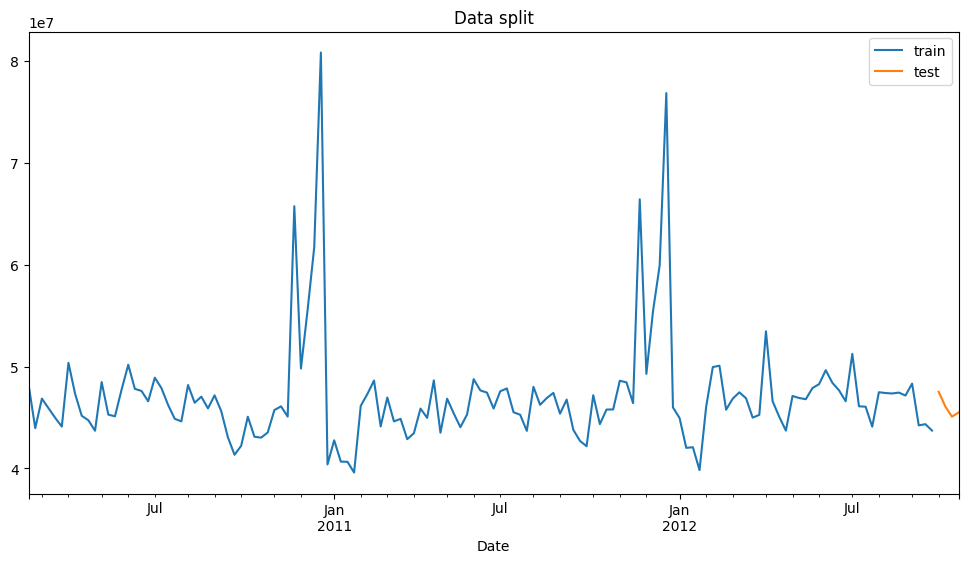

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
y_train.groupby("Date").sum().plot(label="train")
y_test.groupby("Date").sum().plot(label="test")
plt.legend()
plt.title("Data split")
plt.show()

Ahora que ya tenemos los datos, es momento de escalar los datos , en este caso utilizaremos MinMaxScales que escala los datos a un rango arbitrario, por defecto es (0,1), y lo hace restando el valor mínimo a cada componente del vector o columna y dividiendo entre la diferencia entre el valor máximo y el mínimo.

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler1 = MinMaxScaler(feature_range=(0, 1))

tr_df_sc = tr_df.copy()
# definamos las columnas a escalar
sc_col = ['Type', 'Size', 'Temperature', 'Fuel_Price', 
          'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 
          'MarkDown5', 'CPI', 'Unemployment', 'year', 'quarter', 
          'month', 'week'] 
tr_df_sc[sc_col] = scaler.fit_transform(tr_df_sc[sc_col])  # Escala las características
tr_df_sc[["Weekly_Sales"]] = scaler1.fit_transform(tr_df_sc[["Weekly_Sales"]]) # Escala la variable objetivo
tr_df_sc.head()

,Store,Dept,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,IsHoliday_MartinLutherKingJrDay,IsHoliday_MemorialDay,IsHoliday_NewYearsDay,IsHoliday_ThanksgivingDay,IsHoliday_ValentinesDay,IsHoliday_VeteransDay,IsHoliday_WashingtonsBirthday,IsHoliday_WesternEaster,Weekly_Sales_lag1,Weekly_Sales_lag2
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-19,6,95,0.115310,1.0,0.907349,0.446575,0.022876,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81532.73,90278.94
2010-02-19,14,25,0.020668,1.0,0.898651,0.326125,0.148693,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16709.00,19648.50
2010-02-19,17,6,0.009770,0.5,0.315637,0.265362,0.099129,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4976.49,3775.38
2010-02-19,29,21,0.005932,0.5,0.318073,0.332877,0.149782,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3884.38,3680.21
2010-02-19,27,50,0.005545,1.0,0.916437,0.337573,0.238017,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2952.00,2701.00


Ahora, vamos a creear una función que nos devolverá las secuencias y un diccionario que contiene la información correspondiente a cada valor Y que se utlizó en las secuencias como objetivo. Esta función agrupa los datos por `Store` y `Dept`, cada grupo es un un dataframe al que se le sacan las secuencias. En este caso usaremos secuencias de datos de 2 registros.

- `Secuencia`: Cada secuencia es una lista que contiene tanto las `features` como el `target`, con la estructura [features, target]. Aquí, `features es una matriz de dimensión (n, n)`, mientras que target es un valor escalar.

Un aspecto importante a destacar en esta función es que todas las secuencias generadas tendrán la misma longitud. Esto se debe a que la ventana se desliza utilizando el índice [i : i + time_step]. En cada iteración, i se incrementa en una unidad, y la longitud de cada secuencia está determinada por el valor de time_step.

Por ejemplo, si tenemos una lista de datos:

datos = [10, 20, 30, 40, 50, 60]
time_step = 3

Entonces, al aplicar la lógica de la ventana deslizante [i : i + time_step], las secuencias generadas serán:

datos[0:3] → [10, 20, 30] →  target [40]

datos[1:4] → [20, 30, 40] →  target [50]

datos[2:5] → [30, 40, 50] →  target [60]


In [42]:
def crear_secuencia(data, time_steps,drop_cols):
    sequecias = []
    output_list =[]
    for seq, df  in data.groupby(["Store","Dept"]):
        process_df = df.reset_index(drop=True)               # Reseteamos el index del dataframe
        features = process_df.drop(columns=drop_cols).values # Eliminamos las columnas que no se usaran como entradas
        targets = process_df["Weekly_Sales"].values           # Columna objetivo
        # ciclo for para crear las secuencias
        for i in range(len(df)-time_steps):
            feature = features[i:(i+time_steps)]             # hacemos un desplazamiento de la posición actual i + time_step
            target = targets[i+time_steps]                   # el objetivo será el escalar qué esté en la posición i + time_steps
            sequecias.append((feature,target))               # Guarda la secuencia y el target en una lista
            output_list.append({
                'Date':df.index[i+time_steps],
                'Store':df['Store'].iloc[i+time_steps],
                'Dept': df['Dept'].iloc[i+time_steps],
                'Weekly_Sales': df['Weekly_Sales'].iloc[i+time_steps]
            })
    return sequecias, output_list

Cómo ya tenemos la función, procedamos a crear las secuencias.

In [43]:
time_steps = 2  # para la creación de la secuencia solo avanzará dos pasos
drop_cols = ["Store", "Dept", "Weekly_Sales_lag1", "Weekly_Sales_lag2"]
sequences, output_list = crear_secuencia(tr_df_sc, time_steps, drop_cols)
output = pd.DataFrame(output_list)

In [44]:
output.head()

,Date,Store,Dept,Weekly_Sales
0,2010-03-05,1,1,0.031493
1,2010-03-12,1,1,0.030361
2,2010-03-19,1,1,0.031939
3,2010-03-26,1,1,0.037843
4,2010-04-02,1,1,0.082612


Veamos ahora como estan los datos en lista de secuencias

In [45]:
for features, target in enumerate(sequences[1]):
    print(f'Secuencia{features}')
    print(f'objetivo {target}')

Secuencia0
objetivo [[0.02799532 1.         0.63026734 0.47641879 0.04847495 0.
  0.         0.         0.         0.         0.84663781 0.39361079
  0.         0.         0.09090909 0.1372549  0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.03149318 1.         0.63026734 0.47514677 0.08333333 0.
  0.         0.         0.         0.         0.84694069 0.39361079
  0.         0.         0.18181818 0.15686275 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]]
Secuencia1
objetivo 0.030361289036538713


Perfecto, ahora lo que necesitamos es convertir estas secuencias a la forma correcta en que las redes LSTM las reciben. En este caso es `(total_registros, longitud de la secuencia, características)`

In [46]:
X,y = zip(*sequences)
X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

(384090, 2, 30)
(384090,)


# LSTM Single step

Definamos la función que entrenará el modelo